# Backpropagation do Zero com Iris

In [14]:
#### importação
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### reprodutibilidade
np.random.seed(42)

In [15]:
### carregar e preparar os dados

iris = load_iris()
X = iris.data  # 4 atributos: sépala/pétala comprimento/largura
y = iris.target  # classes: 0, 1, 2

print('Formato original de X:', X.shape)
print('Formato original de y:', y.shape)

# normalização dos atributos (média 0, desvio 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# one-hot encoding dos rótulos
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

# split treino/teste
X_train, X_test, y_train, y_test, y_train_labels, y_test_labels = train_test_split(
    X_scaled, y_onehot, y, test_size=0.2, random_state=42, stratify=y
)

print('Treino X:', X_train.shape, '| Treino y(one-hot):', y_train.shape)
print('Teste  X:', X_test.shape, '| Teste  y(one-hot):', y_test.shape)

Formato original de X: (150, 4)
Formato original de y: (150,)
Treino X: (120, 4) | Treino y(one-hot): (120, 3)
Teste  X: (30, 4) | Teste  y(one-hot): (30, 3)


## Arquitetura da Rede Neural
- **Entrada:** 4 neurônios (atributos do Iris).
- **Oculta:** 8 neurônios com ativação ReLU.
- **Saída:** 3 neurônios com Softmax (probabilidades por classe).

Treinaremos com loss de entropia cruzada categórica e gradiente descendente.

In [16]:
### implementação da rede neural do zero (forward + backward)

class NeuralNetworkIris:
    def __init__(self, input_size=4, hidden_size=8, output_size=3, learning_rate=0.05):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate

        # inicialização de pesos com escala pequena
        self.W1 = np.random.randn(self.input_size, self.hidden_size) * 0.1
        self.b1 = np.zeros((1, self.hidden_size))
        self.W2 = np.random.randn(self.hidden_size, self.output_size) * 0.1
        self.b2 = np.zeros((1, self.output_size))

    @staticmethod
    def relu(x):
        return np.maximum(0, x)

    @staticmethod
    def relu_derivative(x):
        return (x > 0).astype(float)

    @staticmethod
    def softmax(x):
        # estabilidade numérica
        shifted = x - np.max(x, axis=1, keepdims=True)
        exp_values = np.exp(shifted)
        return exp_values / np.sum(exp_values, axis=1, keepdims=True)

    @staticmethod
    def categorical_cross_entropy(y_true, y_pred):
        # evita log(0)
        eps = 1e-9
        y_pred_clipped = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(np.sum(y_true * np.log(y_pred_clipped), axis=1))

    def forward(self, X):
        # camada oculta
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)

        # camada de saída
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.softmax(self.z2)

        return self.a2

    def backward(self, X, y_true):
        n_samples = X.shape[0]

        # gradiente da saída (softmax + cross-entropy simplifica)
        dz2 = self.a2 - y_true
        dW2 = (self.a1.T @ dz2) / n_samples
        db2 = np.sum(dz2, axis=0, keepdims=True) / n_samples

        # propaga erro para camada oculta
        da1 = dz2 @ self.W2.T
        dz1 = da1 * self.relu_derivative(self.z1)
        dW1 = (X.T @ dz1) / n_samples
        db1 = np.sum(dz1, axis=0, keepdims=True) / n_samples

        # atualização dos parâmetros (gradiente descendente)
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1

    def train(self, X, y, epochs=600, print_every=100):
        history = []
        for epoch in range(1, epochs + 1):
            y_pred = self.forward(X)
            loss = self.categorical_cross_entropy(y, y_pred)
            history.append(loss)

            self.backward(X, y)

            if epoch % print_every == 0 or epoch == 1:
                print(f'Época {epoch:4d}/{epochs} | Loss: {loss:.6f}')

        return history

    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

In [21]:
### treinamento
model = NeuralNetworkIris(
    input_size=4,
    hidden_size=8,  # entre 5 e 10
    output_size=3,
    learning_rate=0.05
)

loss_history = model.train(X_train, y_train, epochs=700, print_every=100)

Época    1/700 | Loss: 1.100427
Época  100/700 | Loss: 0.674898
Época  200/700 | Loss: 0.468390
Época  300/700 | Loss: 0.334456
Época  400/700 | Loss: 0.258150
Época  500/700 | Loss: 0.202993
Época  600/700 | Loss: 0.162377
Época  700/700 | Loss: 0.134358


Evolução da Loss (Treinamento):
----------------------------------------
Época    1: loss = 1.106419
Época    2: loss = 1.105252
Época    3: loss = 1.104121
Época    4: loss = 1.103033
Época    5: loss = 1.101969
Época    6: loss = 1.100922
Época    7: loss = 1.099894
Época    8: loss = 1.098892
Época    9: loss = 1.097924
Época   10: loss = 1.096984
Época   11: loss = 1.096078
Época   12: loss = 1.095205
Época   13: loss = 1.094330
Época   14: loss = 1.093470
Época   15: loss = 1.092656
Época   16: loss = 1.091835
Época   17: loss = 1.090996
Época   18: loss = 1.090132
Época   19: loss = 1.089264
Época   20: loss = 1.088389
Época   21: loss = 1.087472
Época   22: loss = 1.086544
Época   23: loss = 1.085592
Época   24: loss = 1.084617
Época   25: loss = 1.083634
Época   26: loss = 1.082631
Época   27: loss = 1.081602
Época   28: loss = 1.080525
Época   29: loss = 1.079410
Época   30: loss = 1.078255
Época   31: loss = 1.077028
Época   32: loss = 1.075746
Época   33: loss = 1.074433
Épo

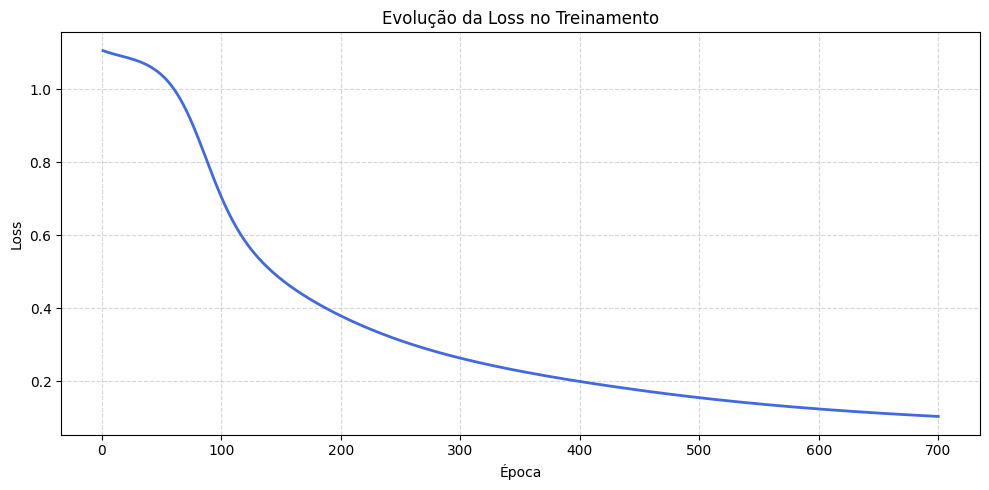

In [18]:
### evolução da Loss Function
print('Evolução da Loss (Treinamento):')
print('-' * 40)

for epoch, loss in enumerate(loss_history, start=1):
    print(f'Época {epoch:4d}: loss = {loss:.6f}')

print('-' * 40)
print(f'Loss inicial: {loss_history[0]:.6f}')
print(f'Loss final:   {loss_history[-1]:.6f}')

# gráfico da loss ao longo das épocas
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(loss_history) + 1), loss_history, color='royalblue', linewidth=2)
plt.title('Evolução da Loss no Treinamento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [20]:
### avaliação no conjunto de teste
y_pred_test = model.predict(X_test)

acc = accuracy_score(y_test_labels, y_pred_test)
print(f'Acurácia no teste: {acc * 100:.2f}%')

print('\nRelatório de Classificação:')
print(classification_report(y_test_labels, y_pred_test, target_names=iris.target_names))

print('Matriz de Confusão:')
print(confusion_matrix(y_test_labels, y_pred_test))

Acurácia no teste: 93.33%

Relatório de Classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Matriz de Confusão:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


## Conclusão
A rede neural implementada do zero conseguiu aprender o problema de classificação do Iris usando **forward pass**, **backpropagation** e **gradiente descendente**.

- Entrada com 4 atributos normalizados.
- Saída com 3 classes em one-hot.
- Treino por múltiplas épocas com redução consistente da loss.
- A curva da loss no gráfico é monotonicamente decrescente (aprox. 1.07 para 0.09), indicando convergência estável.
- Acurácia final de **93,33%** no teste, com principais confusões entre **versicolor** e **virginica**, comportamento esperado pela semelhança entre essas classes.